# LIBRERÍAS

In [ ]:
!pip install ultralytics
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# DETECCIÓN DE OBJETOS


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 91.4ms
Speed: 12.6ms preprocess, 91.4ms inference, 40.9ms postprocess per image at shape (1, 3, 640, 480)


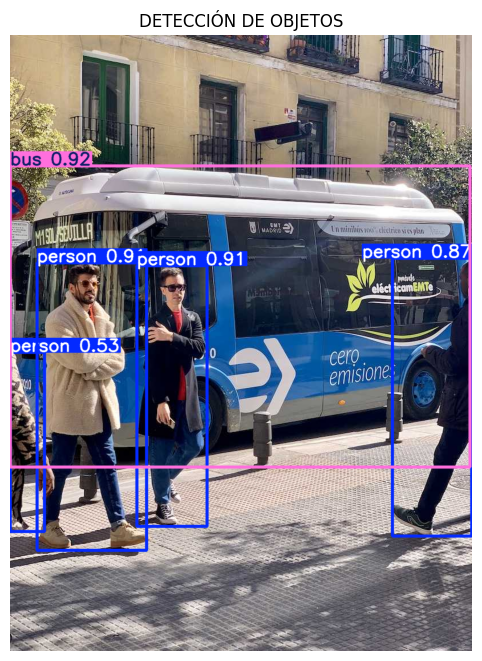

In [ ]:
# Load a model
model = YOLO("yolo26n.pt")  # load an official model
#model = YOLO("path/to/best.pt")  # load a custom model

# Predict with the model
results = model("https://ultralytics.com/images/bus.jpg")  # predict on an image

# Access the results
for result in results:
    xywh = result.boxes.xywh  # center-x, center-y, width, height
    xywhn = result.boxes.xywhn  # normalized
    xyxy = result.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
    xyxyn = result.boxes.xyxyn  # normalized
    names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
    confs = result.boxes.conf  # confidence score of each box

    img_annotated = result.plot()  # devuelve array BGR con keypoints dibujados

    plt.figure(figsize=(10, 8))
    plt.imshow(img_annotated[..., ::-1])  # BGR → RGB
    plt.axis("off")
    plt.title("DETECCIÓN DE OBJETOS")
    plt.show()

PREGUNTAS

¿Qué hace?
Este código carga una imagen y detecta los objetos que aparecen en ella. Básicamente le dice al modelo "analiza esta foto" y él solo identifica qué cosas hay, dónde están (con coordenadas de cada caja), cómo se llaman y qué tan seguro está de haberlas reconocido. Al final muestra la imagen con cajitas dibujadas alrededor de cada objeto.

¿En qué se puede utilizar?
Se puede usar en sistemas de seguridad para detectar personas o vehículos, en tiendas para contar productos en estantes, en carreteras para identificar autos y peatones, o en cualquier app donde necesites saber qué objetos hay dentro de una imagen.

# ESTIMACIÓN DE POSE


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 23.6ms
Speed: 2.1ms preprocess, 23.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)


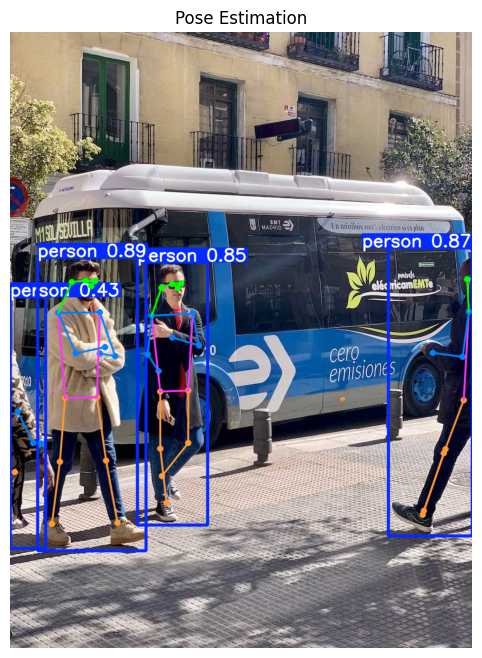

In [ ]:
# Load a model
model = YOLO("yolo26n-pose.pt")  # load an official model
#model = YOLO("path/to/best.pt")  # load a custom model

# IMAGEN PERSONAL
results = model("https://ultralytics.com/images/bus.jpg")

# Access the results
for result in results:
    xy = result.keypoints.xy  # x and y coordinates
    xyn = result.keypoints.xyn  # normalized
    kpts = result.keypoints.data  # x, y, visibility (if available)


    # Renderizar y mostrar la imagen con anotaciones
img_annotated = result.plot()  # devuelve array BGR con keypoints dibujados

plt.figure(figsize=(10, 8))
plt.imshow(img_annotated[..., ::-1])  # BGR → RGB
plt.axis("off")
plt.title("Pose Estimation")
plt.show()

PREGUNTAS

¿Qué hace?
Detecta personas en una imagen y localiza los puntos clave de su cuerpo, como las articulaciones (hombros, codos, rodillas, caderas, etc.). Con esos puntos reconstruye el "esqueleto" de la persona y lo dibuja sobre la imagen para visualizar cómo está posicionado su cuerpo.

¿En qué se puede utilizar?
Es muy útil en aplicaciones de deporte y fitness para analizar la técnica de un atleta, en fisioterapia para monitorear ejercicios de rehabilitación, en videojuegos con control por movimiento, o en sistemas de seguridad que detectan si alguien se cayó o tiene una postura de riesgo.

# SEGMENTACIÓN DE INSTANCIAS


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 33.7ms
Speed: 3.3ms preprocess, 33.7ms inference, 16.5ms postprocess per image at shape (1, 3, 640, 480)


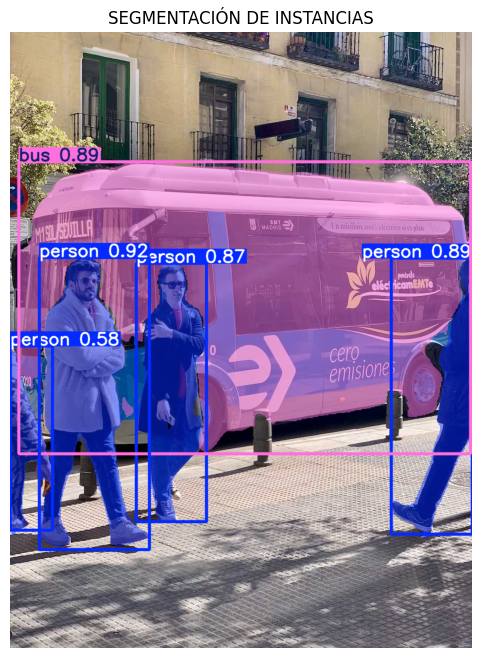

In [ ]:
# Load a model
model = YOLO("yolo26n-seg.pt")  # load an official model
#model = YOLO("path/to/best.pt")  # load a custom model

# Predict with the model
results = model("https://ultralytics.com/images/bus.jpg")  # predict on an image

# Access the results
for result in results:
    xy = result.masks.xy  # mask polygons in pixel coordinates
    xyn = result.masks.xyn  # normalized mask polygons
    masks = result.masks.data  # binary masks, shape (N,H,W), dtype torch.uint8

    img_annotated = result.plot()  # devuelve array BGR con keypoints dibujados

    plt.figure(figsize=(10, 8))
    plt.imshow(img_annotated[..., ::-1])  # BGR → RGB
    plt.axis("off")
    plt.title("SEGMENTACIÓN DE INSTANCIAS")
    plt.show()

PREGUNTAS

¿Qué hace?
Va más allá de solo poner una caja alrededor de los objetos: recorta exactamente la silueta de cada uno. Si hay tres personas en la foto, el modelo crea una máscara precisa para cada una de forma independiente, distinguiéndolas entre sí aunque estén juntas.

¿En qué se puede utilizar?
Sirve para edición de imágenes (recortar personas de fondos automáticamente), en medicina para segmentar órganos o tumores en imágenes clínicas, en robótica para que un brazo mecánico agarre objetos con precisión, o en producción industrial para detectar piezas defectuosas.


# SEGMENTACIÓN SEMÁNTICA


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 1024x768 36.7ms
Speed: 4.7ms preprocess, 36.7ms inference, 21.5ms postprocess per image at shape (1, 3, 1024, 768)


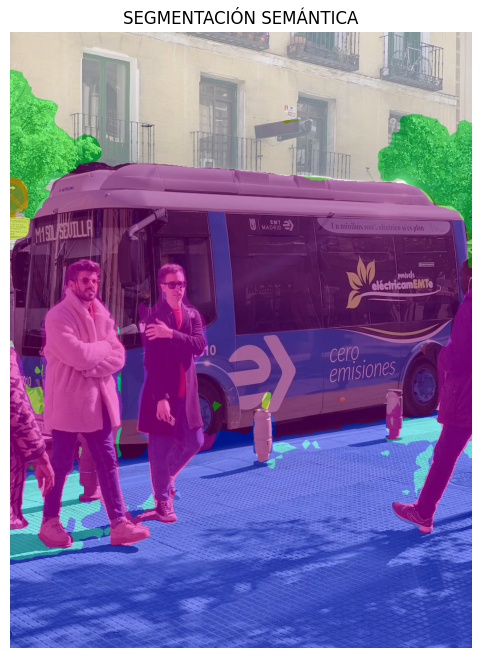

In [ ]:
# Load a model
model = YOLO("yolo26n-sem.pt")  # load an official model
#model = YOLO("path/to/best.pt")  # load a custom model

# Predict with the model
results = model("https://ultralytics.com/images/bus.jpg")  # predict on an image

# Access the results
for result in results:
    semantic_mask = result.semantic_mask.data  # class map, shape (H,W), integer dtype selected by class count
    img_annotated = result.plot()  # devuelve array BGR con keypoints dibujados

    plt.figure(figsize=(10, 8))
    plt.imshow(img_annotated[..., ::-1])  # BGR → RGB
    plt.axis("off")
    plt.title("SEGMENTACIÓN SEMÁNTICA")
    plt.show()

PREGUNTAS

¿Qué hace?
Clasifica cada píxel de la imagen asignándole una categoría (cielo, calle, persona, árbol, etc.). A diferencia de la segmentación de instancias, aquí no distingue entre individuos: si hay dos personas, ambas se marcan igual como "persona". El resultado es un mapa de colores donde cada color representa una clase diferente.

¿En qué se puede utilizar?
Es clave en vehículos autónomos para entender el entorno completo (dónde hay carretera, banqueta, obstáculos), en drones de agricultura para identificar zonas de cultivo sano o enfermo, o en aplicaciones de realidad aumentada para separar elementos de la escena.

# Cuadros delimitadores orientados


image 1/1 /content/boats.jpg: 576x1024 170 ships, 3 harbors, 92.0ms
Speed: 5.9ms preprocess, 92.0ms inference, 0.5ms postprocess per image at shape (1, 3, 576, 1024)


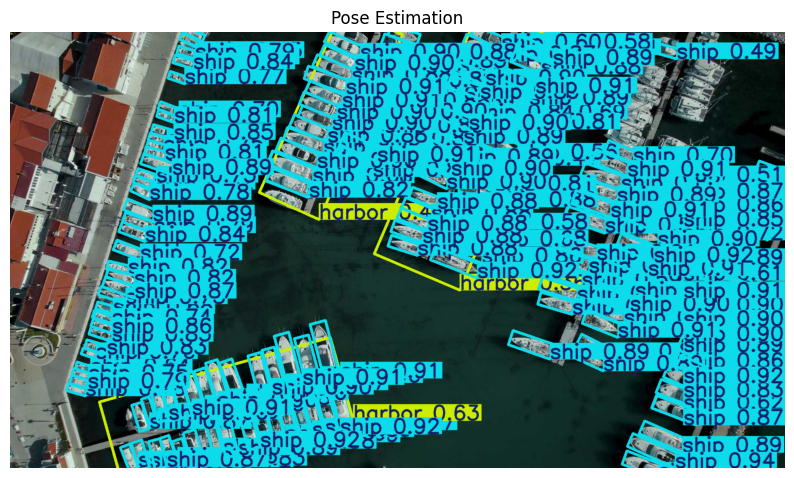

In [ ]:
# Load a model
model = YOLO("yolo26n-obb.pt")  # load an official model
#model = YOLO("path/to/best.pt")  # load a custom model

# Predict with the model
results = model("https://ultralytics.com/images/boats.jpg")  # predict on an image

# Access the results
for result in results:
    xywhr = result.obb.xywhr  # center-x, center-y, width, height, angle (radians)
    xyxyxyxy = result.obb.xyxyxyxy  # polygon format with 4-points
    names = [result.names[cls.item()] for cls in result.obb.cls.int()]  # class name of each box
    confs = result.obb.conf  # confidence score of each box

    img_annotated = result.plot()  # devuelve array BGR con keypoints dibujados

    plt.figure(figsize=(10, 8))
    plt.imshow(img_annotated[..., ::-1])  # BGR → RGB
    plt.axis("off")
    plt.title("Pose Estimation")
    plt.show()

PREGUNTAS

¿Qué hace?
Detecta objetos igual que la detección normal, pero en lugar de poner cajas perfectamente rectas, las rota para que se ajusten mejor al ángulo real del objeto. Por ejemplo, si un barco está diagonal en la imagen, la caja también queda diagonal, lo que da una ubicación mucho más precisa.

¿En qué se puede utilizar?
Es ideal para imágenes satelitales o de drones donde los objetos (barcos, aviones, contenedores) aparecen en distintos ángulos, también en almacenes para detectar cajas apiladas de forma irregular, o en lectura de documentos para detectar texto inclinado.

# CLASIFICACIÓN DE IMÁGENES


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 224x224 minibus 0.52, police_van 0.37, trolleybus 0.10, minivan 0.01, ambulance 0.00, 4.1ms
Speed: 26.1ms preprocess, 4.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)


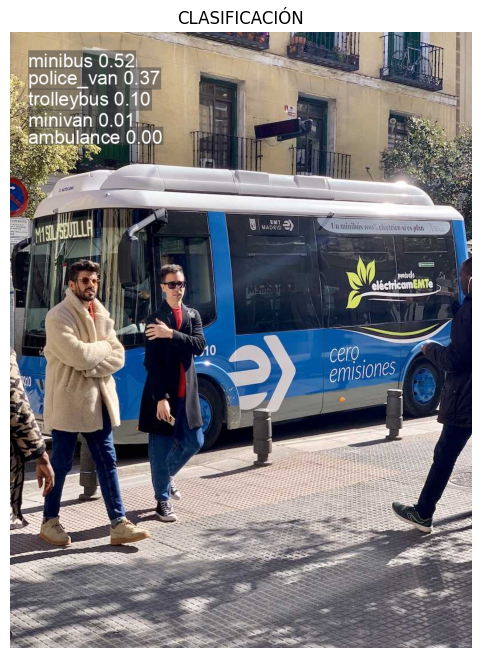

In [ ]:
# Load a model
model = YOLO("yolo26n-cls.pt")  # load an official model
#model = YOLO("path/to/best.pt")  # load a custom model

# Predict with the model
results = model("https://ultralytics.com/images/bus.jpg")  # predict on an image

# Access the results
for result in results:
    top1 = result.probs.top1  # top predicted class ID
    top1_conf = result.probs.top1conf  # top prediction confidence
    top1_name = result.names[top1]  # top predicted class name

    img_annotated = result.plot()  # devuelve array BGR con keypoints dibujados

    plt.figure(figsize=(10, 8))
    plt.imshow(img_annotated[..., ::-1])  # BGR → RGB
    plt.axis("off")
    plt.title("CLASIFICACIÓN")
    plt.show()

PREGUNTAS

¿Qué hace?
Analiza una imagen completa y dice de qué categoría es en general, sin señalar dónde está el objeto. Solo devuelve el nombre de la clase más probable y el porcentaje de confianza. Es la tarea más sencilla: "esta foto es de un autobús, con 95% de certeza".

¿En qué se puede utilizar?
Muy usado en apps de identificación de plantas o animales con la cámara del celular, en sistemas de moderación de contenido para filtrar imágenes inapropiadas, en diagnóstico médico para clasificar radiografías, o en control de calidad para separar productos buenos de defectuosos.


# Segmentación de instancias de vocabulario abierto


image 1/1 /content/bus.jpg: 640x480 5 persons, 1 bus, 231.2ms
Speed: 3.1ms preprocess, 231.2ms inference, 8.7ms postprocess per image at shape (1, 3, 640, 480)


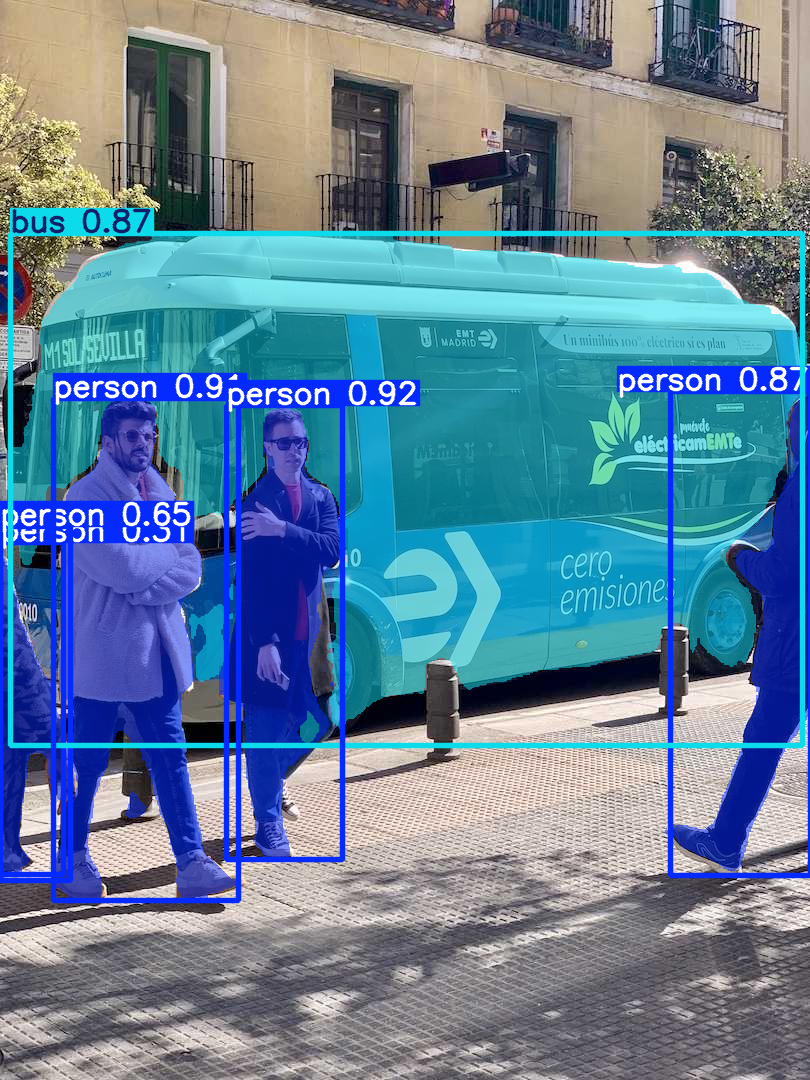

In [ ]:
# Initialize model
model = YOLO("yoloe-26n-seg.pt")  # or select yoloe-26s/m-seg.pt for different sizes

# Set text prompt to detect person and bus. You only need to do this once after you load the model.
model.set_classes(["person", "bus"])

# Run detection on the given image
results = model.predict("/content/bus.jpg")

# Show results
results[0].show()

# PREGUNTAS


1.  ¿Qué hace?
Es como la segmentación de instancias normal, pero con una ventaja enorme: tú le dices al modelo con palabras qué quieres detectar (por ejemplo: "persona" y "autobús"), y él solo busca esas cosas. No está limitado a clases predefinidas, puedes pedirle casi cualquier objeto con texto.

¿En qué se puede utilizar?
Es perfecta cuando necesitas detectar objetos muy específicos sin tener que reentrenar el modelo desde cero, como buscar un tipo particular de herramienta en una fábrica, identificar elementos específicos en imágenes médicas, o construir sistemas de búsqueda visual donde el usuario escribe lo que quiere encontrar.


